*Model Training Code*

In [86]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [87]:
df = pd.read_csv('data/stud.csv')

In [88]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [89]:
X = df.drop(columns='math_score')

In [90]:
X

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75
...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,99,95
996,male,group C,high school,free/reduced,none,55,55
997,female,group C,high school,free/reduced,completed,71,65
998,female,group D,some college,standard,completed,78,77


In [91]:
y = df['math_score']

In [92]:
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

In [93]:
#creating column traisnformers with 3 types of transformers
num_features = X.select_dtypes(exclude="object").columns 
cat_features = X.select_dtypes(include="object").columns 
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

#one hot for categorical and standard for numerical features
preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
        ("StandardScaler", numeric_transformer, num_features)
    ]
)



/var/folders/xf/y6sbnsrs5ws8996_7mnymtr80000gn/T/ipykernel_26920/617410179.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(include="object").columns


In [110]:
X = preprocessor.fit_transform(X)

ValueError: Specifying the columns using strings is only supported for dataframes.

In [111]:
X

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]], shape=(1000, 19))

In [112]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [113]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square


In [114]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "KNN Regressor": KNeighborsRegressor(),
    "Decision Tree Regressor": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "AdaBoost Regressor": AdaBoostRegressor(),
    "Support Vector Regressor": SVR(),
    "CatBoost Regressor": CatBoostRegressor(verbose=False),
    "XGBoost Regressor": XGBRegressor()
}
model_list = []
r2_list=[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print("Model performance for training set")    
    print(f" - Root Mean Squared Error: {model_train_rmse:.4f}")
    print(f" - Mean Absolute Error: {model_train_mae:.4f}")
    print(f" - R2 Score: {model_train_r2:.4f}")

    print('------------------------------------')

    print("Model performance for test set")    
    print(f" - Root Mean Squared Error: {model_test_rmse:.4f}")
    print(f" - Mean Absolute Error: {model_test_mae:.4f}")
    print(f" - R2 Score: {model_train_r2:.4f}")
    r2_list.append(model_test_r2)

    print('='*35)
    print("\n")
    

Linear Regression
Model performance for training set
 - Root Mean Squared Error: 5.3231
 - Mean Absolute Error: 4.2667
 - R2 Score: 0.8743
------------------------------------
Model performance for test set
 - Root Mean Squared Error: 5.3940
 - Mean Absolute Error: 4.2148
 - R2 Score: 0.8743


Ridge Regression
Model performance for training set
 - Root Mean Squared Error: 5.3233
 - Mean Absolute Error: 4.2650
 - R2 Score: 0.8743
------------------------------------
Model performance for test set
 - Root Mean Squared Error: 5.3904
 - Mean Absolute Error: 4.2111
 - R2 Score: 0.8743


Lasso Regression
Model performance for training set
 - Root Mean Squared Error: 6.5938
 - Mean Absolute Error: 5.2063
 - R2 Score: 0.8071
------------------------------------
Model performance for test set
 - Root Mean Squared Error: 6.5197
 - Mean Absolute Error: 5.1579
 - R2 Score: 0.8071


KNN Regressor
Model performance for training set
 - Root Mean Squared Error: 5.7172
 - Mean Absolute Error: 4.5270
 -

In [115]:
pd.DataFrame(list(zip(model_list, r2_list)), columns = ['Model', 'R2 Score'])

,Model,R2 Score
0,Linear Regression,0.880433
1,Ridge Regression,0.880593
2,Lasso Regression,0.825320
3,KNN Regressor,0.783681
4,Decision Tree Regressor,0.742334
5,Random Forest Regressor,0.847035
6,AdaBoost Regressor,0.856558
7,Support Vector Regressor,0.728600
8,CatBoost Regressor,0.851632
9,XGBoost Regressor,0.827797


In [116]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(f"R2 Score: {score:.2f}%")

R2 Score: 88.04%


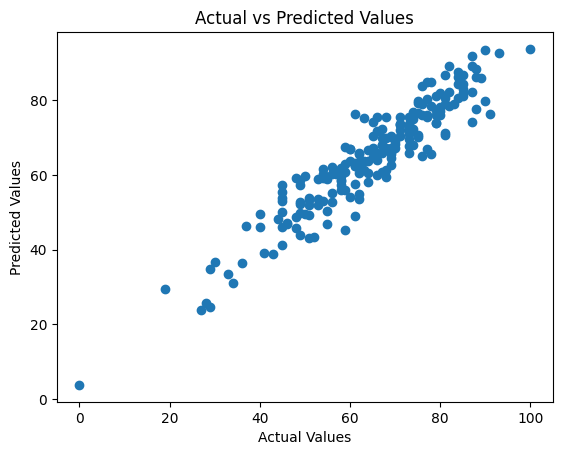

In [117]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

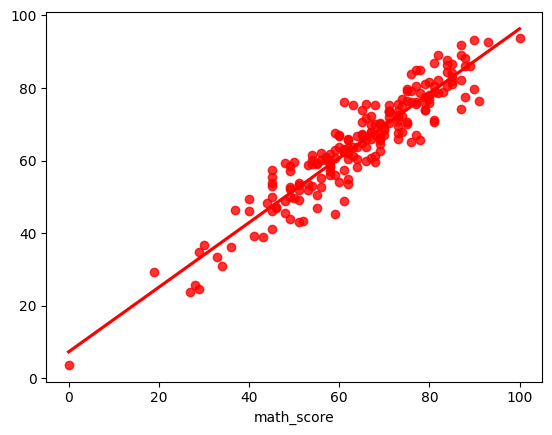

In [118]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red');

In [120]:
pred_df = pd.DataFrame({'Actual Value':y_test, 'Predicted Value':y_pred, 'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
